In [118]:
# Import necessary libraries 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import tensorflow 
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Input,Dense

# What is Vanishing Gradient Problem ? 
##### In machine learning, the vanishing gradient problem is the problem of greatly diverging gradient magnitudes between earlier and later layers encountered when training neural networks with backpropagation. In such methods, neural network weights are updated proportional to their partial derivative of the loss function.[1] As the number of forward propagation steps in a network increases, for instance due to greater network depth, the gradients of earlier weights are calculated with increasingly many multiplications. These multiplications shrink the gradient magnitude. Consequently, the gradients of earlier weights will be exponentially smaller than the gradients of later weights. This difference in gradient magnitude might introduce instability in the training process, slow it, or halt it entirely.[1] For instance, consider the hyperbolic tangent activation function. The gradients of this function are in range [0,1]. The product of repeated multiplication with such gradients decreases exponentially. The inverse problem, when weight gradients at earlier layers get exponentially larger, is called the exploding gradient problem.


source : https://en.wikipedia.org/wiki/Vanishing_gradient_problem

In [119]:
# We will use the make_moons function to create a non-linear dataset and we will be here using the sigmoid function to classify the classes
X,y = make_moons(
                    n_samples = 250, # No of rows
                    random_state = 7,
                    noise = 0.05 # Noise to the points
)

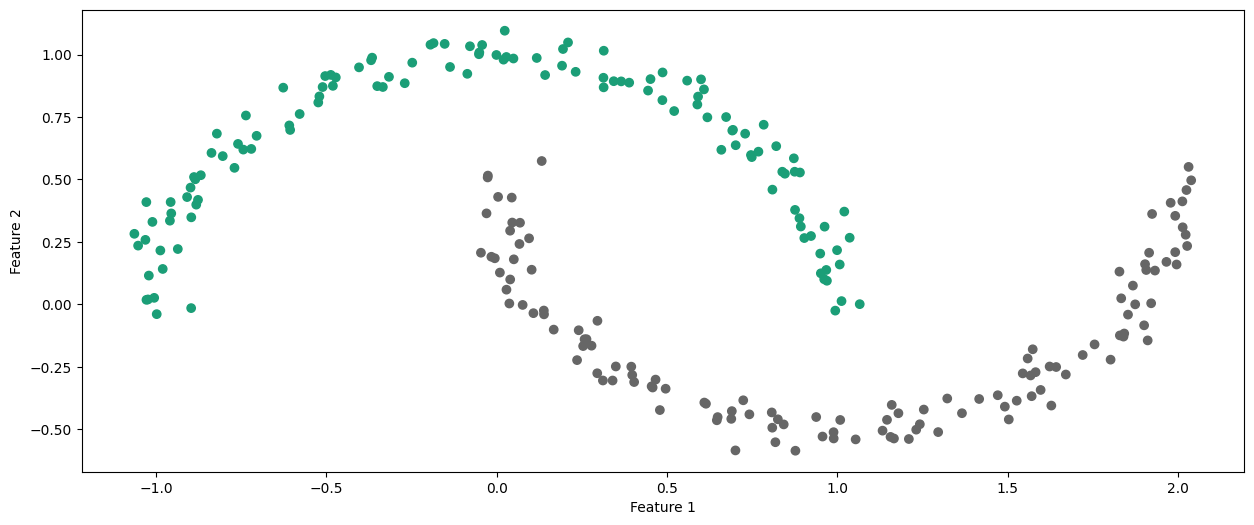

In [120]:
# Now lets plot this into a graph

plt.figure(figsize=(15,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='Dark2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [121]:
# Now let's create our model 
# Now the model we are creating first will have a lot of layers so that we can see whether the vanishing gradient problem exists or not

In [122]:
model = Sequential()
model.add(Input(shape=(X.shape[1],)))

# At first we will take 10 layers to check how this complexity affects vanishing gradient

model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))

model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

In [123]:
# Now lets skim the parameters and the model
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 921 (3.60 KB)

 Trainable params: 921 (3.60 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
# Now lets compile the model and set loss , metrics and optimizer for our classifier
model.compile(
                loss='binary_crossentropy',
                optimizer='SGD',
                metrics=['accuracy']
            )


In [125]:
# Now we will fetch the old weights so we can compare this with the new weight later

In [126]:
old_parameters = model.get_weights()[0]

In [127]:
old_parameters # The initial values

array([[-0.5220858 ,  0.55663127, -0.12807196, -0.1687516 , -0.08446956,
        -0.24273214, -0.38011584, -0.703221  , -0.22248039,  0.2958458 ],
       [-0.46828857, -0.24464324, -0.07634395,  0.04520249,  0.47346574,
         0.45672232, -0.26494083, -0.26505226, -0.6310828 ,  0.6953358 ]],
      dtype=float32)

In [128]:
# Now we will split X,y and into training and testing set
X_train , X_test , y_train , y_test = train_test_split(
                                                            X,y,
                                                            test_size = 0.2,
                                                            random_state = 7
)

In [129]:
# Now lets fit the trainig sets into the model

In [130]:
model.fit(
            X_train,
            y_train,
            epochs = 100
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5100 - loss: 0.6993
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5100 - loss: 0.6983 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5100 - loss: 0.6978 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5100 - loss: 0.6975 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5100 - loss: 0.6966
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5100 - loss: 0.6954
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5100 - loss: 0.6954 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5100 - loss: 0.6946
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5100 - loss: 0.6946
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5100 - loss: 0.6943 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5100 - loss: 0.6944 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.510

In [131]:
# Store the new weights
new_parameters = model.get_weights()[0]

In [132]:
# Get the learning rate 
learning_rate  = model.optimizer.get_config()["learning_rate"]

In [133]:
# Calculate the gradient by the formulae = gradient = (Wold - Wnew)/learning_rate
gradient = ( old_parameters - new_parameters )/learning_rate

# Also lets calculate the percentage_change across the old and new values
percent_change = abs(100*(old_parameters - new_parameters)/ old_parameters)

In [134]:
# Lets quickly look at the new and old parameters before peeking at the gradient

In [135]:
old_parameters

array([[-0.5220858 ,  0.55663127, -0.12807196, -0.1687516 , -0.08446956,
        -0.24273214, -0.38011584, -0.703221  , -0.22248039,  0.2958458 ],
       [-0.46828857, -0.24464324, -0.07634395,  0.04520249,  0.47346574,
         0.45672232, -0.26494083, -0.26505226, -0.6310828 ,  0.6953358 ]],
      dtype=float32)

In [136]:
new_parameters

array([[-0.5220858 ,  0.55663127, -0.12807196, -0.1687516 , -0.08446955,
        -0.24273184, -0.38011584, -0.703221  , -0.22248027,  0.2958458 ],
       [-0.46828857, -0.24464324, -0.07634395,  0.04520249,  0.47346574,
         0.45672232, -0.26494083, -0.26505226, -0.6310828 ,  0.6953358 ]],
      dtype=float32)

In [137]:
# The gradient
gradient

array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        -7.4505806e-07, -2.9802322e-05,  0.0000000e+00,  0.0000000e+00,
        -1.1920929e-05,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00]], dtype=float32)

In [138]:
# The percent change
percent_change

array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        8.8204333e-06, 1.2277864e-04, 0.0000000e+00, 0.0000000e+00,
        5.3581931e-05, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [139]:
# As you can see the percent change is quite less for the parameters

In [140]:
# This is the diminishing gradient problem